In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# read NetMedGPT results
plot_dir = "/home/bbc8731/BioMedFormer/data/plot/random_split/"
data_dir_biomedformer_randomLinkSplit = "/home/bbc8731/BioMedFormer/data/result/biomedformer_atr_transductive_wl5_wpn30_dim300_head5_lencoder30_bs4000_lr0.0001_20250705_122538/"

Lp_test_random = pd.read_csv(os.path.join(data_dir_biomedformer_randomLinkSplit, "LP_test.csv"))
recall_precision_test_random = pd.read_csv(os.path.join(data_dir_biomedformer_randomLinkSplit, "hit_precision_test.csv"))

# Group by seed
grouped = Lp_test_random.groupby('seed')
grouped_recall = recall_precision_test_random.groupby('seed')

indication_aucs_netmedgpt = grouped.nth(0)['auc']
contraindication_aucs_netmedgpt = grouped.nth(1)['auc']
offlabel_aucs_netmedgpt = grouped.nth(2)['auc']
drugprotein_aucs_netmedgpt = grouped.nth(3)['auc']
drugeffect_aucs_netmedgpt = grouped.nth(4)['auc']

indication_recall100_netmedgpt = grouped_recall.nth(0)['hit']
contraindication_recall100_netmedgpt = grouped_recall.nth(1)['hit']
offlabel_recall100_netmedgpt = grouped_recall.nth(2)['hit']
drugprotein_recall100_netmedgpt = grouped_recall.nth(3)['hit']
drugeffect_recall100_netmedgpt = grouped_recall.nth(4)['hit']

###### find mean and std of auc
mean_indication_aucs_netmedgpt = round(indication_aucs_netmedgpt.mean(), 3)
mean_contraindication_aucs_netmedgpt = round(contraindication_aucs_netmedgpt.mean(), 3)
mean_offlabel_aucs_netmedgpt = round(offlabel_aucs_netmedgpt.mean(), 3)
mean_drugprotein_aucs_netmedgpt = round(drugprotein_aucs_netmedgpt.mean(), 3)
mean_drugeffect_aucs_netmedgpt = round(drugeffect_aucs_netmedgpt.mean(), 3)

std_indication_aucs_netmedgpt = round(indication_aucs_netmedgpt.std(), 3)
std_contraindication_aucs_netmedgpt = round(contraindication_aucs_netmedgpt.std(), 3)
std_offlabel_aucs_netmedgpt = round(offlabel_aucs_netmedgpt.std(), 3)
std_drugprotein_aucs_netmedgpt = round(drugprotein_aucs_netmedgpt.std(), 3)
std_drugeffect_aucs_netmedgpt = round(drugeffect_aucs_netmedgpt.std(), 3)

##### find mean and std of recall@100
mean_indication_recall100_netmedgpt = round(indication_recall100_netmedgpt.mean(), 3)
mean_contraindication_recall100_netmedgpt = round(contraindication_recall100_netmedgpt.mean(), 3)
mean_offlabel_recall100_netmedgpt = round(offlabel_recall100_netmedgpt.mean(), 3)
mean_drugprotein_recall100_netmedgpt = round(drugprotein_recall100_netmedgpt.mean(), 3)
mean_drugeffect_recall100_netmedgpt = round(drugeffect_recall100_netmedgpt.mean(), 3)

std_indication_recall100_netmedgpt = round(indication_recall100_netmedgpt.std(), 3)
std_contraindication_recall100_netmedgpt = round(contraindication_recall100_netmedgpt.std(), 3)
std_offlabel_recall100_netmedgpt = round(offlabel_recall100_netmedgpt.std(), 3)
std_drugprotein_recall100_netmedgpt = round(drugprotein_recall100_netmedgpt.std(), 3)
std_drugeffect_recall100_netmedgpt = round(drugeffect_recall100_netmedgpt.std(), 3)

In [3]:
# read TxGNN results
txgnn_results = pd.read_csv("/home/bbc8731/BioMedFormer/data/TxGNN_results/result_more_metrics.csv")
txgnn_random = txgnn_results.loc[txgnn_results['Split'] == 'random',:]

#####################################################
indication_rows = []
contraindication_rows = []

for i in txgnn_random['Metric Name'].unique():
    metric_i = txgnn_random.loc[txgnn_random['Metric Name'] == i,:]

    for j in metric_i['Method'].unique():
        method_j = metric_i.loc[metric_i['Method'] == j,:]

        indi = method_j.loc[method_j['Task'] == 'indication', 'Metric']
        contra = method_j.loc[method_j['Task'] == 'contraindication', 'Metric']

        mean_indication = np.nanmean(indi) if not indi.empty else np.nan
        std_indication = np.nanstd(indi) if not indi.empty else np.nan
        indication_rows.append([j, i, mean_indication, std_indication])

        mean_contraindication = np.nanmean(contra) if not contra.empty else np.nan
        std_contraindication  = np.nanstd(contra)  if not contra.empty else np.nan
        contraindication_rows.append([j, i, mean_contraindication, std_contraindication])

# build final DataFrames
indication_res = pd.DataFrame(indication_rows, columns=['method','Metric','mean','std'])
contraindication_res = pd.DataFrame(contraindication_rows, columns=['method','Metric','mean','std'])

In [4]:
# read GNN results for three other tasks 
data_dir_GNN = "/home/bbc8731/BioMedFormer/data/"
RGCN_drugprotein = pd.read_csv(os.path.join(data_dir_GNN, "ray_tune_RGCN_drug_gene_new/auprc_('drug', 'drug_protein', 'gene').csv"))
RGCN_drugADR = pd.read_csv(os.path.join(data_dir_GNN, "ray_tune_RGCN_drug_ADR_new/auprc_('drug', 'drug_effect', 'phenotype').csv"))
RGCN_drugofflabel = pd.read_csv(os.path.join(data_dir_GNN, "ray_tune_RGCN_offlabel_new/auprc_('disease', 'offlabel', 'drug').csv"))

HAN_drugprotein = pd.read_csv(os.path.join(data_dir_GNN, "ray_tune_HAN_drug_gene_new/auprc_('drug', 'drug_protein', 'gene').csv"))
HAN_drugADR = pd.read_csv(os.path.join(data_dir_GNN, "ray_tune_HAN_drug_ADR_new/auprc_('drug', 'drug_effect', 'phenotype').csv"))
HAN_drugofflabel = pd.read_csv(os.path.join(data_dir_GNN, "ray_tune_HAN_offlabel_new/auprc_('disease', 'offlabel', 'drug').csv"))

HGT_drugprotein = pd.read_csv(os.path.join(data_dir_GNN, "ray_tune_HGT_drug_gene_new/auprc_('drug', 'drug_protein', 'gene').csv"))
HGT_drugADR = pd.read_csv(os.path.join(data_dir_GNN, "ray_tune_HGT_drug_ADR_new/auprc_('drug', 'drug_effect', 'phenotype').csv"))
HGT_drugofflabel = pd.read_csv(os.path.join(data_dir_GNN, "ray_tune_HGT_offlabel_new/auprc_('disease', 'offlabel', 'drug').csv"))

#### identify mean and std for auc
# RGCN
mean_drugprotein_auc_RGCN = round(np.mean(RGCN_drugprotein['auc']), 3)
std_drugprotein_auc_RGCN = round(np.std(RGCN_drugprotein['auc']), 3)

mean_drugADR_auc_RGCN = round(np.mean(RGCN_drugADR['auc']), 3)
std_drugADR_auc_RGCN = round(np.std(RGCN_drugADR['auc']), 3)

mean_drugofflabel_auc_RGCN = round(np.mean(RGCN_drugofflabel['auc']), 3)
std_drugofflabel_auc_RGCN = round(np.std(RGCN_drugofflabel['auc']), 3)

# HAN
mean_drugprotein_auc_HAN = round(np.mean(HAN_drugprotein['auc']), 3)
std_drugprotein_auc_HAN = round(np.std(HAN_drugprotein['auc']), 3)

mean_drugADR_auc_HAN = round(np.mean(HAN_drugADR['auc']), 3)
std_drugADR_auc_HAN = round(np.std(HAN_drugADR['auc']), 3)

mean_drugofflabel_auc_HAN = round(np.mean(HAN_drugofflabel['auc']), 3)
std_drugofflabel_auc_HAN = round(np.std(HAN_drugofflabel['auc']), 3)

# HGT
mean_drugprotein_auc_HGT = round(np.mean(HGT_drugprotein['auc']), 3)
std_drugprotein_auc_HGT = round(np.std(HGT_drugprotein['auc']), 3)

mean_drugADR_auc_HGT = round(np.mean(HGT_drugADR['auc']), 3)
std_drugADR_auc_HGT = round(np.std(HGT_drugADR['auc']), 3)

mean_drugofflabel_auc_HGT = round(np.mean(HGT_drugofflabel['auc']), 3)
std_drugofflabel_auc_HGT = round(np.std(HGT_drugofflabel['auc']), 3)

#### identify mean and std for recall@100
# RGCN
mean_drugprotein_recall_RGCN = round(np.mean(RGCN_drugprotein['recall100']), 3)
std_drugprotein_recall_RGCN = round(np.std(RGCN_drugprotein['recall100']), 3)

mean_drugADR_recall_RGCN = round(np.mean(RGCN_drugADR['recall100']), 3)
std_drugADR_recall_RGCN = round(np.std(RGCN_drugADR['recall100']), 3)

mean_drugofflabel_recall_RGCN = round(np.mean(RGCN_drugofflabel['recall100']), 3)
std_drugofflabel_recall_RGCN = round(np.std(RGCN_drugofflabel['recall100']), 3)

# HAN
mean_drugprotein_recall_HAN = round(np.mean(HAN_drugprotein['recall100']), 3)
std_drugprotein_recall_HAN = round(np.std(HAN_drugprotein['recall100']), 3)

mean_drugADR_recall_HAN = round(np.mean(HAN_drugADR['recall100']), 3)
std_drugADR_recall_HAN = round(np.std(HAN_drugADR['recall100']), 3)

mean_drugofflabel_recall_HAN = round(np.mean(HAN_drugofflabel['recall100']), 3)
std_drugofflabel_recall_HAN = round(np.std(HAN_drugofflabel['recall100']), 3)

# HGT
mean_drugprotein_recall_HGT = round(np.mean(HGT_drugprotein['recall100']), 3)
std_drugprotein_recall_HGT = round(np.std(HGT_drugprotein['recall100']), 3)

mean_drugADR_recall_HGT = round(np.mean(HGT_drugADR['recall100']), 3)
std_drugADR_recall_HGT = round(np.std(HGT_drugADR['recall100']), 3)

mean_drugofflabel_recall_HGT = round(np.mean(HGT_drugofflabel['recall100']), 3)
std_drugofflabel_recall_HGT = round(np.std(HGT_drugofflabel['recall100']), 3)


In [5]:
# indication 
# compute AUC
indication_aucs_other = indication_res.loc[indication_res['Metric'] == 'AUROC',:]

new_row = pd.DataFrame(
    [['NetMedGPT', 'AUROC', mean_indication_aucs_netmedgpt, std_indication_aucs_netmedgpt]],
    columns=['method','Metric','mean','std']
)
indication_aucs = pd.concat([indication_aucs_other, new_row], ignore_index=True)

#####################
# compute Recall@100
indication_recall100_other = indication_res.loc[indication_res['Metric'] == 'Recall@100',:]

new_row = pd.DataFrame(
    [['NetMedGPT', 'Recall@100', mean_indication_recall100_netmedgpt, std_indication_recall100_netmedgpt]],
    columns=['method','Metric','mean','std']
)

indication_recall100 = pd.concat([indication_recall100_other, new_row], ignore_index=True)

In [6]:
# contraindication
# compute AUC
contraindication_aucs_other = contraindication_res.loc[contraindication_res['Metric'] == 'AUROC',:]

new_row = pd.DataFrame(
    [['NetMedGPT', 'AUROC', mean_contraindication_aucs_netmedgpt, std_contraindication_aucs_netmedgpt]],
    columns=['method','Metric','mean','std']
)
contraindication_aucs = pd.concat([contraindication_aucs_other, new_row], ignore_index=True)

#####################
# compute Recall@100
contraindication_recall100_other = contraindication_res.loc[contraindication_res['Metric'] == 'Recall@100',:]

new_row = pd.DataFrame(
    [['NetMedGPT', 'Recall@100', mean_contraindication_recall100_netmedgpt, std_contraindication_recall100_netmedgpt]],
    columns=['method','Metric','mean','std']
)
contraindication_recall100 = pd.concat([contraindication_recall100_other, new_row], ignore_index=True)

In [7]:
# off-label 
# compute AUC
drugofflabel_aucs = pd.DataFrame(
    [['RGCN', 'AUROC', mean_drugofflabel_auc_RGCN, std_drugofflabel_auc_RGCN],
     ['HAN', 'AUROC', mean_drugofflabel_auc_HAN, std_drugofflabel_auc_HAN],
     ['HGT', 'AUROC', mean_drugofflabel_auc_HGT, std_drugofflabel_auc_HGT],
     ['NetMedGPT', 'AUROC', mean_offlabel_aucs_netmedgpt, std_offlabel_aucs_netmedgpt]],
    columns=['method','Metric','mean','std']
)

#####################
# compute Recall@100
drugofflabel_recall = pd.DataFrame(
    [['RGCN', 'AUROC', mean_drugofflabel_recall_RGCN, std_drugofflabel_recall_RGCN],
     ['HAN', 'AUROC', mean_drugofflabel_recall_HAN, std_drugofflabel_recall_HAN],
     ['HGT', 'AUROC', mean_drugofflabel_recall_HGT, std_drugofflabel_recall_HGT],
     ['NetMedGPT', 'AUROC', mean_offlabel_recall100_netmedgpt, std_offlabel_recall100_netmedgpt]],
    columns=['method','Metric','mean','std']
)

In [8]:
# drug-protein
# compute AUC
drugprotein_aucs = pd.DataFrame(
    [['RGCN', 'AUROC', mean_drugprotein_auc_RGCN, std_drugprotein_auc_RGCN],
     ['HAN', 'AUROC', mean_drugprotein_auc_HAN, std_drugprotein_auc_HAN],
     ['HGT', 'AUROC', mean_drugprotein_auc_HGT, std_drugprotein_auc_HGT],
     ['NetMedGPT', 'AUROC', mean_drugprotein_aucs_netmedgpt, std_drugprotein_aucs_netmedgpt]],
    columns=['method','Metric','mean','std']
)

#####################
# compute Recall@100
drugprotein_recall = pd.DataFrame(
    [['RGCN', 'AUROC', mean_drugprotein_recall_RGCN, std_drugprotein_recall_RGCN],
     ['HAN', 'AUROC', mean_drugprotein_recall_HAN, std_drugofflabel_recall_HAN],
     ['HGT', 'AUROC', mean_drugprotein_recall_HGT, std_drugofflabel_recall_HGT],
     ['NetMedGPT', 'AUROC', mean_drugprotein_recall100_netmedgpt, std_drugprotein_recall100_netmedgpt]],
    columns=['method','Metric','mean','std']
)


In [9]:
# drug-effect
# compute AUC
drugADR_aucs = pd.DataFrame(
    [['RGCN', 'AUROC', mean_drugADR_auc_RGCN, std_drugADR_auc_RGCN],
     ['HAN', 'AUROC', mean_drugADR_auc_HAN, std_drugADR_auc_HAN],
     ['HGT', 'AUROC', mean_drugADR_auc_HGT, std_drugADR_auc_HGT],
     ['NetMedGPT', 'AUROC', mean_drugeffect_aucs_netmedgpt, std_drugeffect_aucs_netmedgpt]],
    columns=['method','Metric','mean','std']
)

#####################
# compute Recall@100
drugADR_recall = pd.DataFrame(
    [['RGCN', 'AUROC', mean_drugADR_recall_RGCN, std_drugADR_recall_RGCN],
     ['HAN', 'AUROC', mean_drugADR_recall_HAN, std_drugADR_recall_HAN],
     ['HGT', 'AUROC', mean_drugADR_recall_HGT, std_drugADR_recall_HGT],
     ['NetMedGPT', 'AUROC', mean_drugeffect_recall100_netmedgpt, std_drugeffect_recall100_netmedgpt]],
    columns=['method','Metric','mean','std']
)


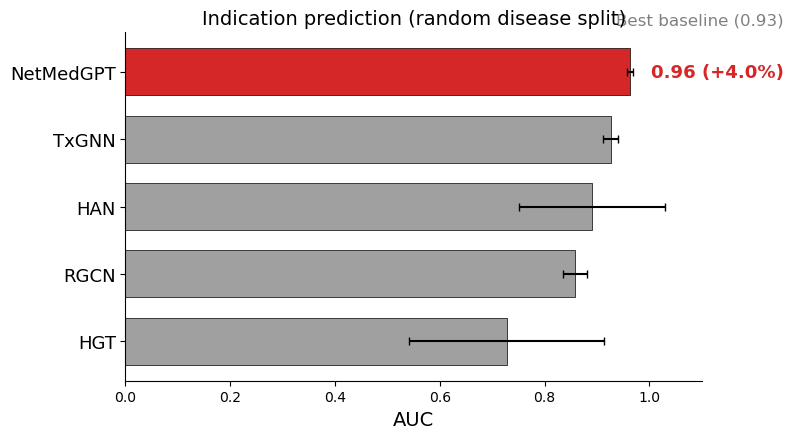

In [10]:
# AUC values for indication–random split
methods = indication_aucs['method'][[3,4,5,7,9]]
means = indication_aucs['mean'][[3,4,5,7,9]]
stds = indication_aucs['std'][[3,4,5,7,9]]

# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
ax.text(baseline_max + 0.01, -0.7, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.04, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUC", fontsize=14)
ax.set_title("Indication prediction (random disease split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Save
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "auc_netmedgpt_indication_random_split.png"), dpi=300, bbox_inches="tight")
plt.show()


In [11]:
indication_recall100

,method,Metric,mean,std
0,DSD-min,Recall@100,0.012431,0.006469
1,KL-min,Recall@100,0.007190,0.005406
2,JS-min,Recall@100,0.012110,0.004170
3,HGT,Recall@100,0.292965,0.241226
4,HAN,Recall@100,0.568947,0.267595
5,RGCN,Recall@100,0.312100,0.019297
6,BioBERT,Recall@100,0.126775,0.024675
7,TxGNN,Recall@100,0.428717,0.019742
8,Proximity,Recall@100,0.011388,0.003708
9,NetMedGPT,Recall@100,0.857000,0.017000


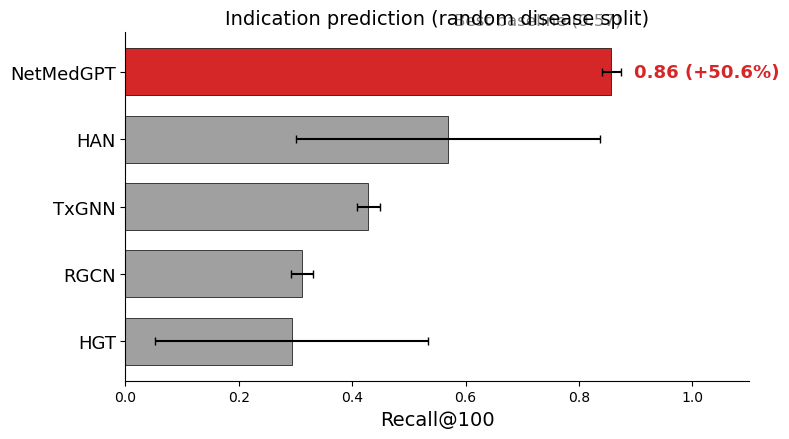

In [12]:
# Recall values for indication–random split
methods = indication_recall100['method'][[3,4,5,7,9]]
means = indication_recall100['mean'][[3,4,5,7,9]]
stds = indication_recall100['std'][[3,4,5,7,9]]

# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
ax.text(baseline_max + 0.01, -0.7, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.04, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("Recall@100", fontsize=14)
ax.set_title("Indication prediction (random disease split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Save
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "recall_netmedgpt_indication_random_split.png"), dpi=300, bbox_inches="tight")
plt.show()


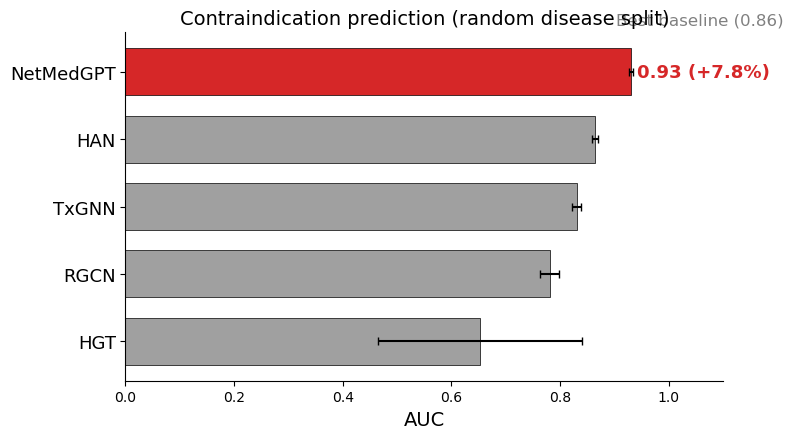

In [13]:
# AUC values for contraindication–random split
methods = contraindication_aucs['method'][[3,4,5,7,9]]
means = contraindication_aucs['mean'][[3,4,5,7,9]]
stds = contraindication_aucs['std'][[3,4,5,7,9]]

# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
ax.text(baseline_max + 0.04, -0.7, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUC", fontsize=14)
ax.set_title("Contraindication prediction (random disease split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Save
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "auc_netmedgpt_contraindication_random_split.png"), dpi=300, bbox_inches="tight")
plt.show()


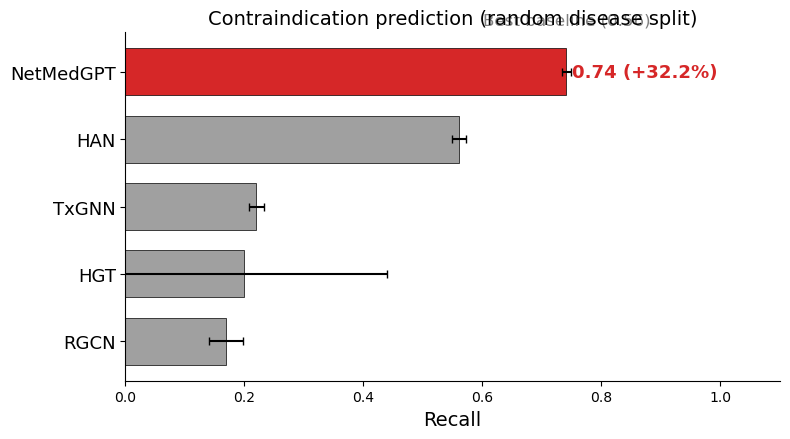

In [14]:
# Recall values for contraindication–random split
methods = contraindication_recall100['method'][[3,4,5,7,9]]
means = contraindication_recall100['mean'][[3,4,5,7,9]]
stds = contraindication_recall100['std'][[3,4,5,7,9]]

# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
ax.text(baseline_max + 0.04, -0.7, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("Recall", fontsize=14)
ax.set_title("Contraindication prediction (random disease split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Save
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "recall_netmedgpt_contraindication_random_split.png"), dpi=300, bbox_inches="tight")
plt.show()


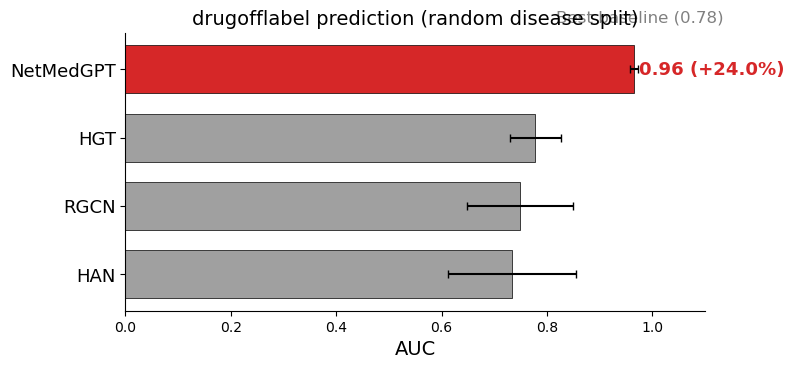

In [15]:
# AUC values for drugofflabel–random split
methods = drugofflabel_aucs['method']
means = drugofflabel_aucs['mean']
stds = drugofflabel_aucs['std']

# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
ax.text(baseline_max + 0.04, -0.7, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUC", fontsize=14)
ax.set_title("drugofflabel prediction (random disease split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Save
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "auc_netmedgpt_drugofflabel_random_split.png"), dpi=300, bbox_inches="tight")
plt.show()


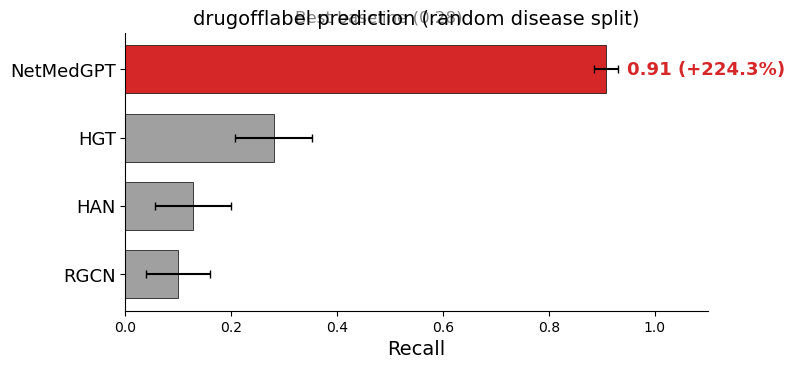

In [16]:
# Recall values for drugofflabel–random split
methods = drugofflabel_recall['method']
means = drugofflabel_recall['mean']
stds = drugofflabel_recall['std']

# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))

y_pos = np.arange(len(methods))
bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
ax.text(baseline_max + 0.04, -0.7, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.04, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("Recall", fontsize=14)
ax.set_title("drugofflabel prediction (random disease split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Save
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "recall_netmedgpt_drugofflabel_random_split.png"), dpi=300, bbox_inches="tight")
plt.show()


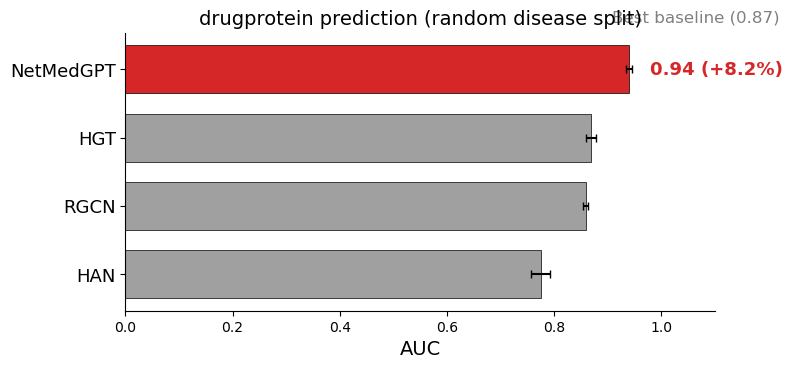

In [17]:
# AUC values for drugprotein–random split
methods = drugprotein_aucs['method']
means = drugprotein_aucs['mean']
stds = drugprotein_aucs['std']

# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
ax.text(baseline_max + 0.04, -0.7, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.04, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUC", fontsize=14)
ax.set_title("drugprotein prediction (random disease split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Save
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "auc_netmedgpt_drugprotein_random_split.png"), dpi=300, bbox_inches="tight")
plt.show()


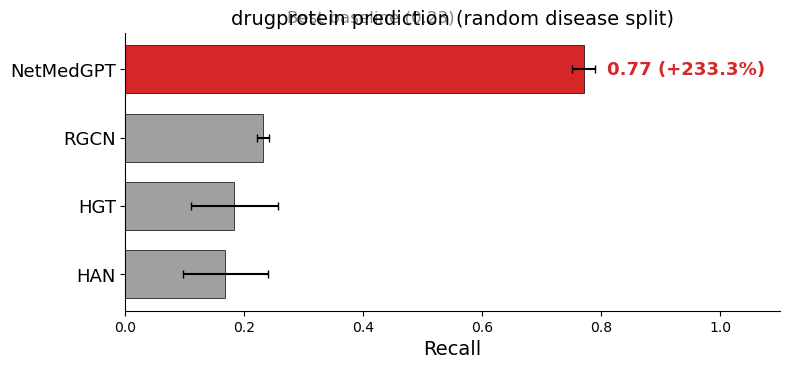

In [18]:
# Recall values for drugprotein–random split
methods = drugprotein_recall['method']
means = drugprotein_recall['mean']
stds = drugprotein_recall['std']

# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))

y_pos = np.arange(len(methods))
bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
ax.text(baseline_max + 0.04, -0.7, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.04, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("Recall", fontsize=14)
ax.set_title("drugprotein prediction (random disease split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Save
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "recall_netmedgpt_drugprotein_random_split.png"), dpi=300, bbox_inches="tight")
plt.show()


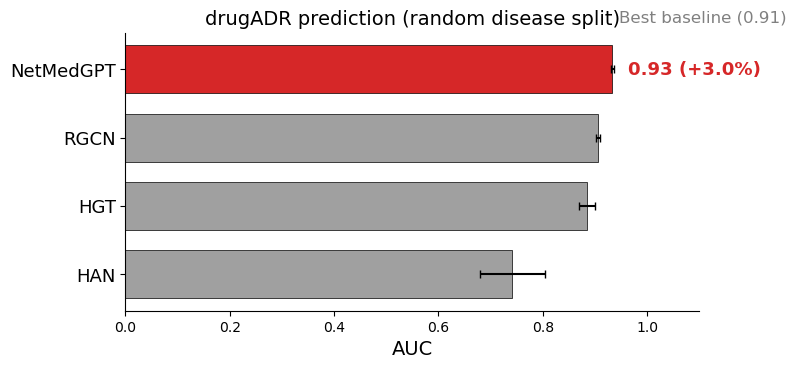

In [19]:
# AUC values for drugADR–random split
methods = drugADR_aucs['method']
means = drugADR_aucs['mean']
stds = drugADR_aucs['std']

# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
ax.text(baseline_max + 0.04, -0.7, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.03, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUC", fontsize=14)
ax.set_title("drugADR prediction (random disease split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Save
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "auc_netmedgpt_drugADR_random_split.png"), dpi=300, bbox_inches="tight")
plt.show()


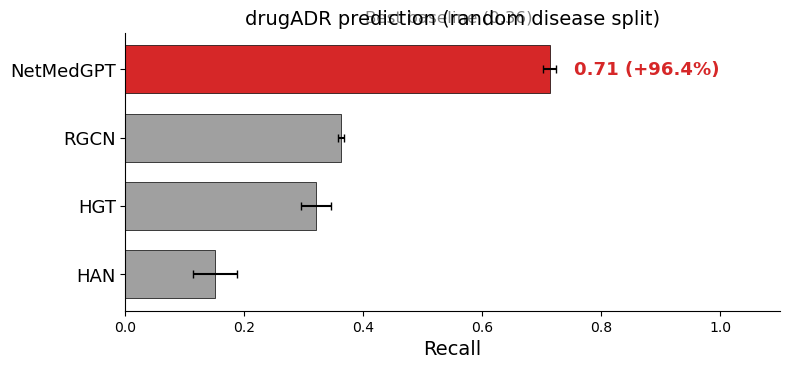

In [20]:
# Recall values for drugADR–random split
methods = drugADR_recall['method']
means = drugADR_recall['mean']
stds = drugADR_recall['std']

# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))

y_pos = np.arange(len(methods))
bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
ax.text(baseline_max + 0.04, -0.7, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.04, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("Recall", fontsize=14)
ax.set_title("drugADR prediction (random disease split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Save
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "recall_netmedgpt_drugADR_random_split.png"), dpi=300, bbox_inches="tight")
plt.show()
